In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

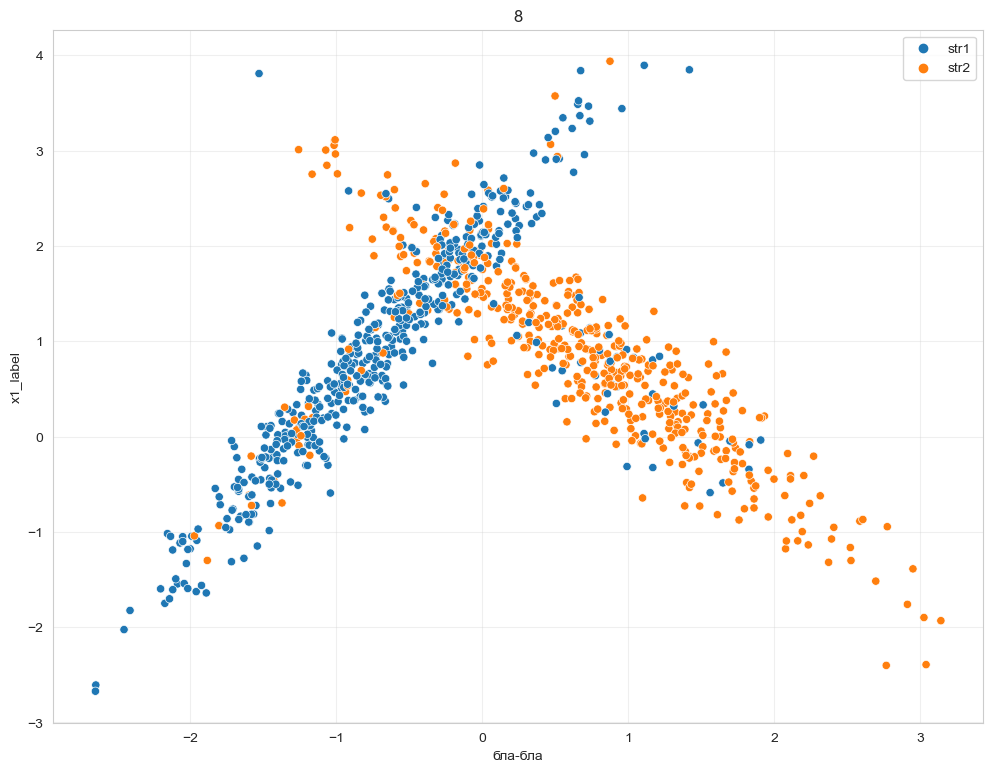

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# ----------------------------------------------
# ГЕНЕРАТОР ДАТАСЕТА
# ----------------------------------------------

def generate_noise_dataset(
    n_samples=25,        # Сколько всего точек (должно быть чётным для баланса)
    noise_ratio=0.05,     # Доля шумовых точек (5% — это наглядно)
    class_sep=10,        # Разделимость классов (чем меньше, тем ближе облака)
    random_state=42       # Фиксируем сид, чтобы всё было воспроизводимо
):
    # 1. Генерируем «чистые» данные
    # n_informative = 2 — используем оба признака для разделения
    # n_redundant = 0 — без лишних признаков
    # flip_y = noise_ratio — вероятность, что метка будет перепутана (это и есть наш шум)
    X, y = make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        flip_y=noise_ratio,          # <-- Вот он, наш шум!
        class_sep=class_sep,
        random_state=random_state
    )

    # 2. Превращаем в датафрейм для удобства
    df = pd.DataFrame(X, columns=['x1', 'x2'])
    df['target'] = y    
    df['class_name'] = df['target'].map({0: 'str1', 1: 'str2'})

    return df, X, y

# ----------------------------------------------
# ВИЗУАЛИЗАЦИЯ
# ----------------------------------------------

def plot_noise_dataset(df, x1_label, x2_label):
    plt.figure(figsize=(12, 9))
    sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'class_name', alpha=1)
    plt.xlabel(x1_label)
    plt.ylabel(x2_label)
    plt.title(k)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
# ----------------------------------------------
# ПОДБОР РАНДОМА = 11
# ----------------------------------------------

for k in range(8, 9):

    df, X, y = generate_noise_dataset(
        n_samples=1000,
        noise_ratio=0.2,
        class_sep=0.8,
        random_state=42
    )

    plot_noise_dataset(df, x1_label = 'бла-бла', x2_label = 'x1_label')

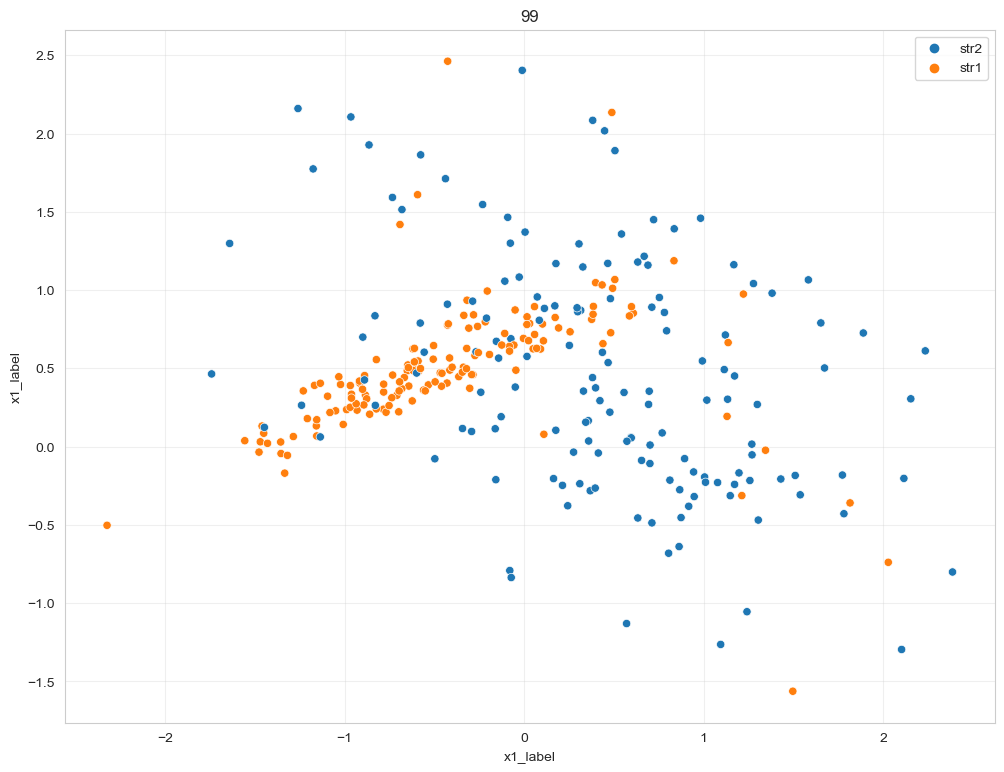

k = 5
k = 10
k = 15
k = 20
k = 25


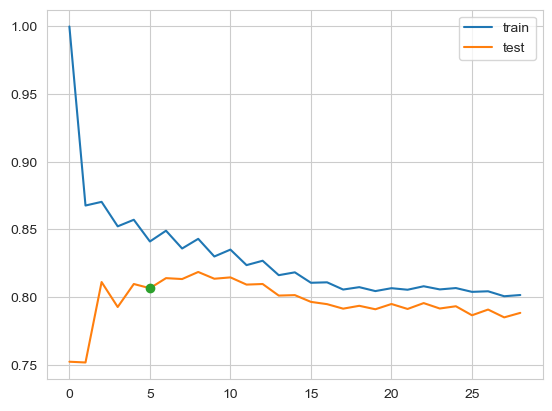

In [45]:
df, X, y = generate_noise_dataset(
                                  n_samples=300,
                                  noise_ratio=0.2,
                                  class_sep=0.5,
                                  random_state=42
                                  )

plot_noise_dataset(df, x1_label = 'x1_label', x2_label = 'x1_label')

X = df.drop(columns = ['target', 'class_name'])
y = df['target']

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(1, round(10*len(df)/100)):
    
    if k % 5 == 0:
        print('k =', k)
    
    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(100):
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        
        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())
    
plt.plot(Accuracy_train_list, label = 'train')
plt.plot(Accuracy_test_list, label = 'test')
plt.plot([5], Accuracy_test_list[5], 'o')
plt.legend()
plt.show()

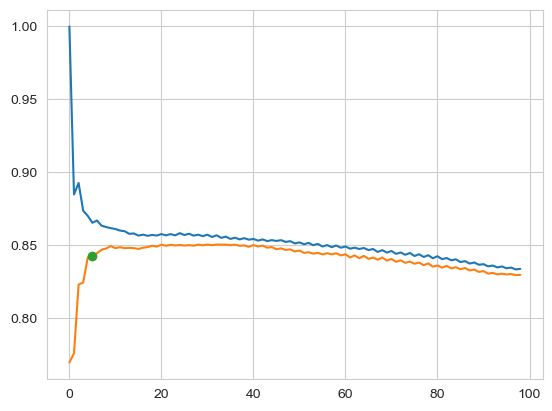

In [44]:
plt.plot(Accuracy_train_list)
plt.plot(Accuracy_test_list)
plt.plot([5], Accuracy_test_list[5], 'o')

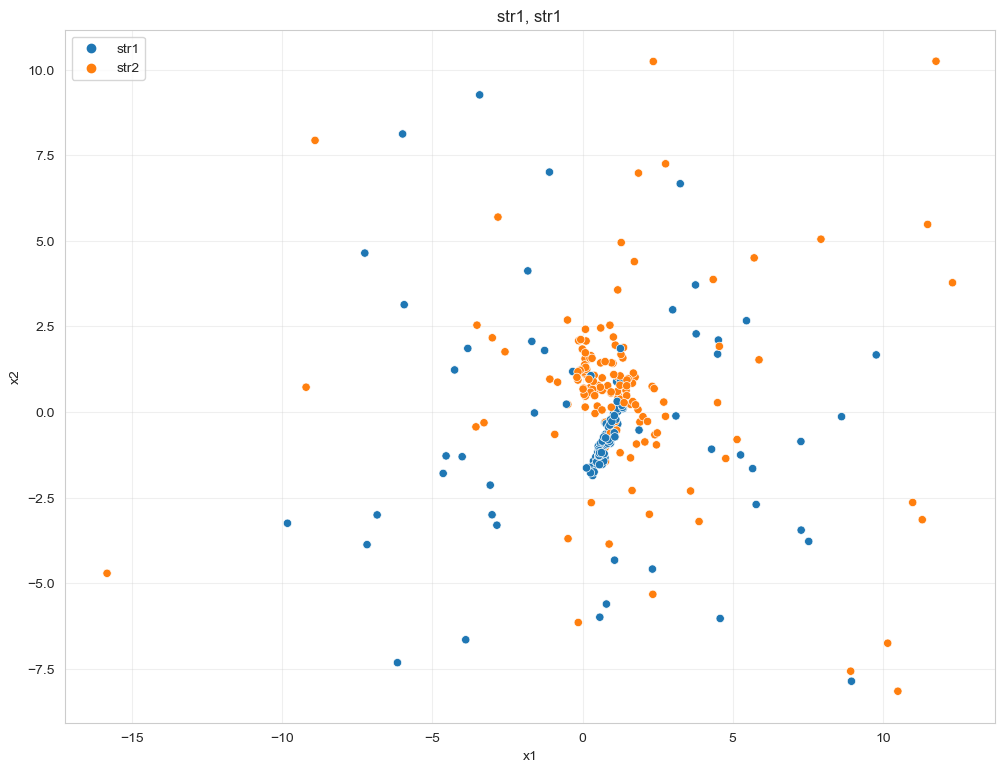

In [57]:
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import numpy as np

# Генерируем данные с умеренной сложностью
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,  # Низкая разделимость
    flip_y=0.05,
    random_state=42
)

# Добавляем нелинейность: создаём "островки"
# Ближайшие точки одного класса сдвигаем в сторону другого
rng = np.random.RandomState(42)
mask = rng.rand(len(X)) < 0.3  # 30% точек
X[mask] = X[mask] + rng.normal(0, 5.0, size=(mask.sum(), 2))

# Теперь у тебя будут локальные "карманы" —
# маленький k их поймает, большой k размоет
df = pd.DataFrame(data = X, columns = ['x1', 'x2'])
df['target'] = y
df['class_name'] = df['target'].map({0: 'str1', 1: 'str2'})


plt.figure(figsize=(12, 9))
sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'class_name', alpha=1)
plt.title(df['class_name'].unique()[0] + ', ' + df['class_name'].unique()[0])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

k = 5
k = 10
k = 15
k = 20
k = 25


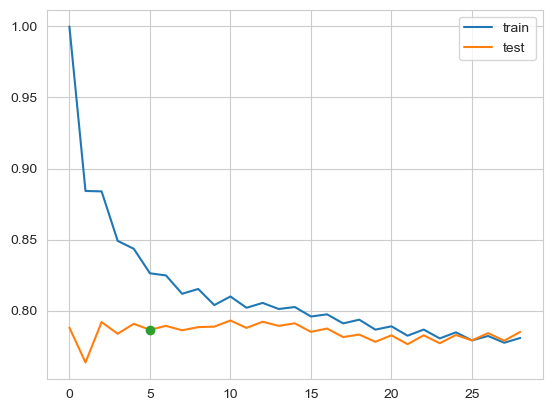

In [58]:
X = df.drop(columns = ['target', 'class_name'])
y = df['target']

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(1, round(10*len(df)/100)):
    
    if k % 5 == 0:
        print('k =', k)
    
    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(100):
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        
        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())
    
plt.plot(Accuracy_train_list, label = 'train')
plt.plot(Accuracy_test_list, label = 'test')
plt.plot([5], Accuracy_test_list[5], 'o')
plt.legend()
plt.show()

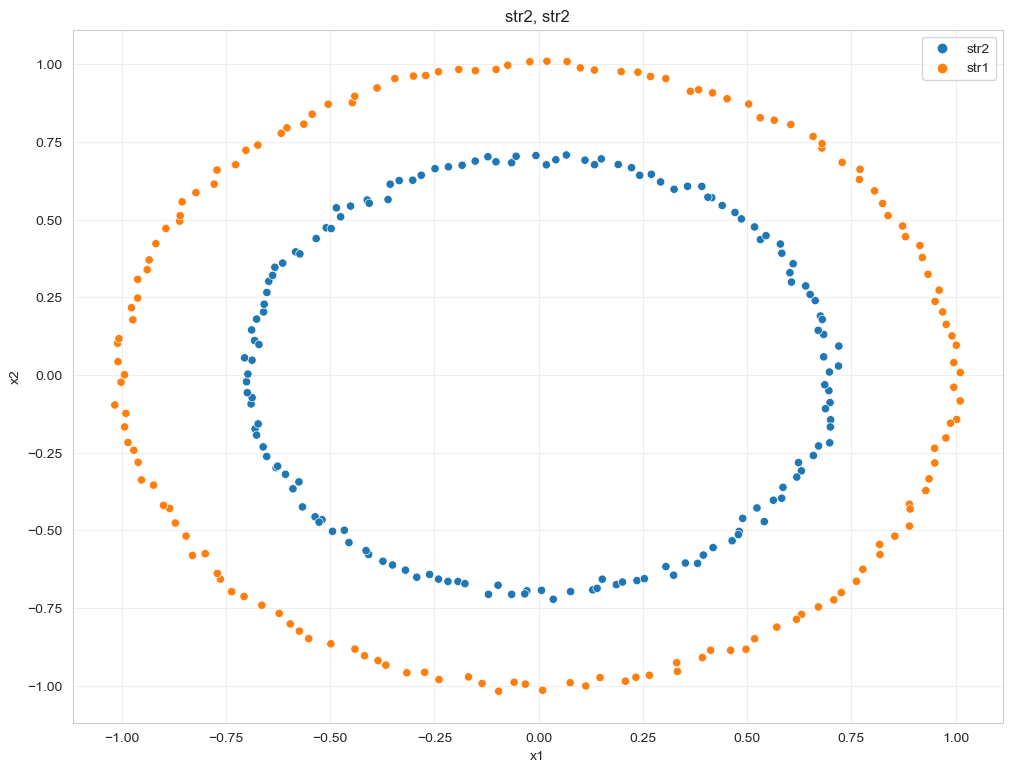

k = 5
k = 10
k = 15
k = 20
k = 25


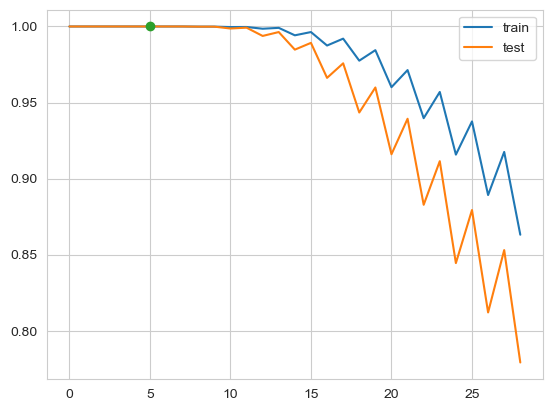

In [72]:
from sklearn.datasets import make_moons
X, y = make_circles(n_samples=300, noise=0.01, factor=0.7, random_state=42)

df = pd.DataFrame(data = X, columns = ['x1', 'x2'])
df['target'] = y
df['class_name'] = df['target'].map({0: 'str1', 1: 'str2'})


plt.figure(figsize=(12, 9))
sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'class_name', alpha=1)
plt.title(df['class_name'].unique()[0] + ', ' + df['class_name'].unique()[0])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

X = df.drop(columns = ['target', 'class_name'])
y = df['target']

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(1, round(10*len(df)/100)):
    
    if k % 5 == 0:
        print('k =', k)
    
    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(100):
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        
        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())
    
plt.plot(Accuracy_train_list, label = 'train')
plt.plot(Accuracy_test_list, label = 'test')
plt.plot([5], Accuracy_test_list[5], 'o')
plt.legend()
plt.show()

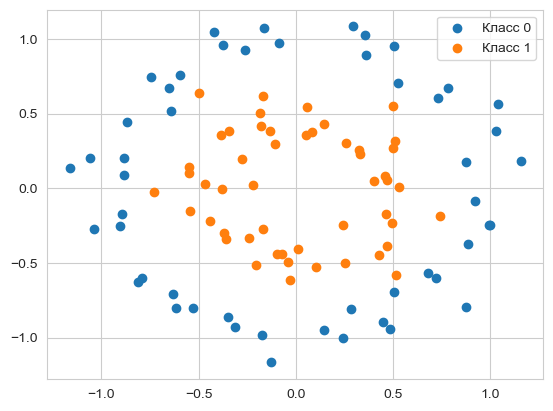

In [67]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Генерация данных
X, y = make_circles(n_samples=100, noise=0.1, factor=0.5, random_state=42)

# Визуализация
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Класс 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Класс 1')
plt.legend()
plt.show()

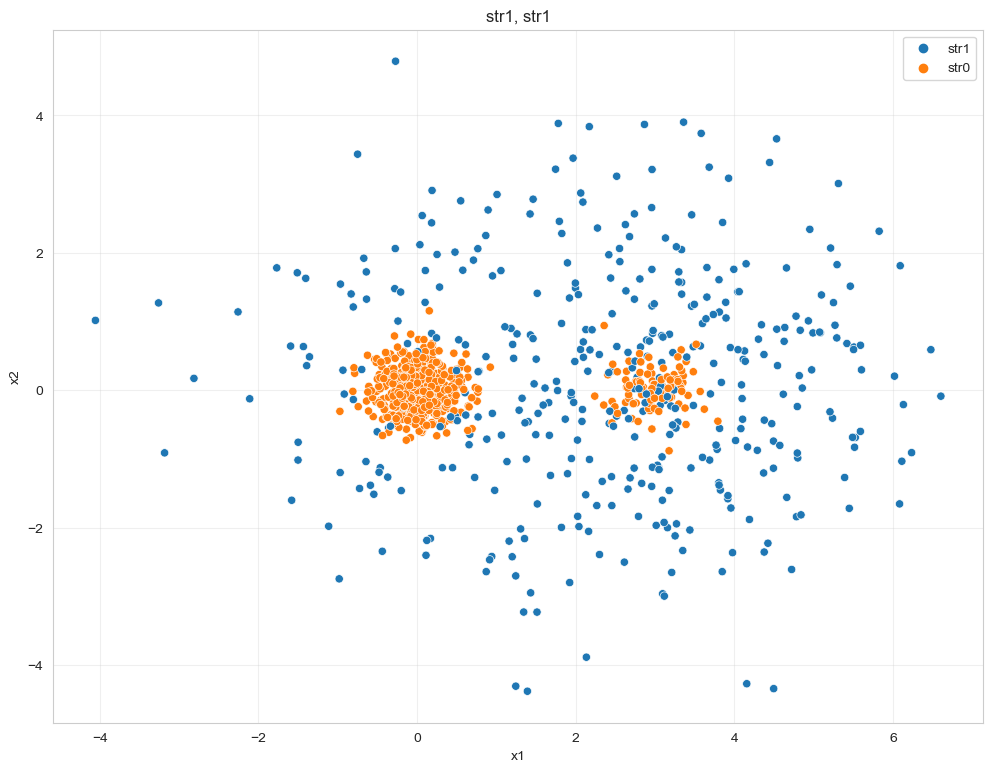

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Класс 0: компактное облако в центре
X0 = np.random.normal(loc=[0, 0], scale=0.3, size=(500, 2))
y0 = np.zeros(500)

# Класс 1: широкое облако в стороне
X1 = np.random.normal(loc=[3, 0], scale=1.5, size=(300, 2))
y1 = np.ones(300)

# Добавляем "карманы" в класс 0 — точки класса 1 глубоко внутри территории класса 0
# Это рыхлый карман, его плотность такая же, как и у его родного класса 1
X1_islands = np.random.normal(loc=[0, 0], scale=1.5, size=(100, 2))
y1_islands = np.ones(100)

# Добавляем "карманы" в класс 1 — точки класса 0 глубоко внутри территории класса 1
# Это компактный карман, его плотность такая же, как и у его родного класса 0
X0_islands = np.random.normal(loc=[3, 0], scale=0.3, size=(100, 2))
y0_islands = np.zeros(100)

# Собираем всё
X = np.vstack([X1_islands, X0_islands, X0, X1])
y = np.concatenate([y1_islands, y0_islands, y0, y1])

# Реализуем как датафрейм

df = pd.DataFrame(data = X, columns = ['x1', 'x2'])
df['target'] = y
df['class_name'] = df['target'].map({0: 'str0', 1: 'str1'})

# Перемешиваем строки
df = df.sample(len(df))

# Рисуем картинку
plt.figure(figsize=(12, 9))
sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'class_name', alpha=1)
plt.title(df['class_name'].unique()[0] + ', ' + df['class_name'].unique()[0])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

k = 5
k = 10
k = 15
k = 20
k = 25
k = 30
k = 35
k = 40
k = 45


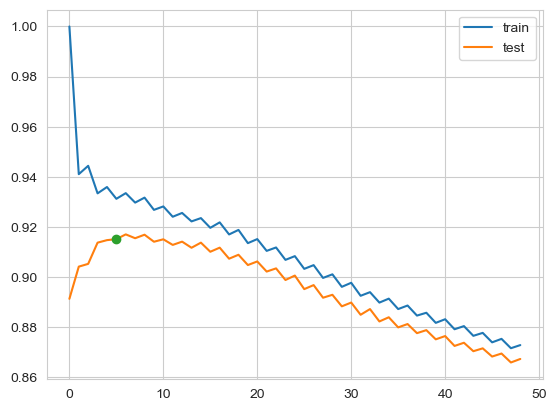

[0.8913666666666668, 0.9042, 0.9053, 0.9137666666666666, 0.9147666666666666, 0.9151666666666667, 0.9170666666666666, 0.9155333333333333, 0.9169333333333333, 0.9141333333333332, 0.9151, 0.9128666666666667, 0.9141666666666665, 0.9117333333333333, 0.9137666666666666, 0.9101333333333333, 0.9117666666666667, 0.9073666666666667, 0.9089333333333333, 0.9048333333333335, 0.9062666666666667, 0.9022333333333333, 0.9035, 0.8988666666666666, 0.9006333333333333, 0.8952333333333332, 0.8968333333333333, 0.8917999999999999, 0.8929666666666666, 0.8883666666666666, 0.8898666666666667, 0.885, 0.8872666666666668, 0.8823333333333333, 0.8839999999999999, 0.8799666666666667, 0.8813000000000001, 0.8776666666666668, 0.8788666666666667, 0.8752000000000001, 0.8765000000000001, 0.8725666666666666, 0.8738333333333332, 0.8704666666666665, 0.8715999999999998, 0.8683333333333333, 0.8695333333333334, 0.8659666666666667, 0.8673666666666666]


In [117]:
#Делаем предикторы и таргет
X = df.drop(columns = ['target', 'class_name'])
y = df['target']

# Списки для итоговых значенией accuracy
Accuracy_train_list = []
Accuracy_test_list = []

# Цикл по числу соседей до 5% от общего числа объектов
for k in range(1, round(5*len(df)/100)):
    
    # Счетчик, чтобы был виден прогресс исполнения (цикл долгий, и не понятно, скоро ли конец)
    if k % 5 == 0:
        print('k =', k)
    
    # Списки для текущих значенией accuracy при каждом разбиениина train и test
    accuracy_train_list = []
    accuracy_test_list = []
    
    # Цикл по случайным разбиениям на train и test
    for seed in range(100):
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        
        # Наполняем списки accuracy
        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)
        
    # Наполняем итоговые списки accuracy усредненными метриками для каждого случайного разбиения на train и test
    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

# Рисуем картинку для себя
plt.plot(Accuracy_train_list, label = 'train')
plt.plot(Accuracy_test_list, label = 'test')
plt.plot([5], Accuracy_test_list[5], 'o')
plt.legend()
plt.show()

# Выводим список accuracy на teste для Маруськи
print(Accuracy_test_list)

In [119]:
print(list(np.array(Accuracy_test_list).round(4)))

[0.8914, 0.9042, 0.9053, 0.9138, 0.9148, 0.9152, 0.9171, 0.9155, 0.9169, 0.9141, 0.9151, 0.9129, 0.9142, 0.9117, 0.9138, 0.9101, 0.9118, 0.9074, 0.9089, 0.9048, 0.9063, 0.9022, 0.9035, 0.8989, 0.9006, 0.8952, 0.8968, 0.8918, 0.893, 0.8884, 0.8899, 0.885, 0.8873, 0.8823, 0.884, 0.88, 0.8813, 0.8777, 0.8789, 0.8752, 0.8765, 0.8726, 0.8738, 0.8705, 0.8716, 0.8683, 0.8695, 0.866, 0.8674]


In [122]:
# Плотное облако класса 0
X0 = np.random.normal(loc=[0, 0], scale=1.0, size=(500, 2))
y0 = np.zeros(500)

# Рыхлое облако класса 1, размазанное широким гауссом
X1 = np.random.normal(loc=[0, 0], scale=3.0, size=(500, 2))
y1 = np.ones(500)

# Добавляем умеренный разделительный сигнал (оба облака близко, но смещены)
X1[:, 0] += 1.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

acc_k5 = accuracy_score(y_test, KNeighborsClassifier(5).fit(X_train, y_train).predict(X_test))
acc_k21 = accuracy_score(y_test, KNeighborsClassifier(21).fit(X_train, y_train).predict(X_test))

print(f"k=5: {acc_k5:.4f}")
print(f"k=21: {acc_k21:.4f}")
print(f"Прирост: {acc_k21 - acc_k5:.4f}")


k=5: 0.9267
k=21: 0.9267
Прирост: 0.0000


In [160]:
np.random.seed(42)

# Класс 0: компактное облако
X0 = np.random.normal(loc=[0, 0], scale=1, size=(500, 2))
y0 = np.zeros(500)

# Класс 1: компактное облако в стороне
X1 = np.random.normal(loc=[3, 0], scale=1, size=(500, 2))
y1 = np.ones(500)

# А ТЕПЕРЬ КЛЮЧЕВОЕ — добавляем ШУМОВЫЕ признаки
noise_features = np.random.normal(0, 2.5, size=(1000, 18))  # 48 useless features!

X0 = np.hstack([X0, noise_features[:500]])
X1 = np.hstack([X1, noise_features[500:]])

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])
len(y)

1000

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


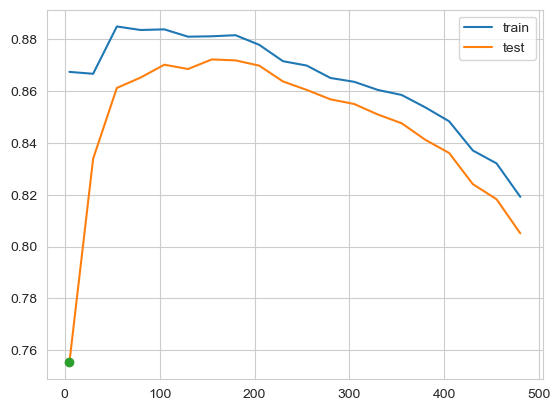

In [161]:
horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(50*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(100):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.legend()
plt.show()

In [171]:
print('Последовательность скоров:')
print(list(np.array(Accuracy_test_list).round(4)))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4))
print('При n_neighbors =', np.argmax(np.array(Accuracy_test_list))*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

Последовательность скоров:
[0.7553, 0.8339, 0.8613, 0.8653, 0.8702, 0.8686, 0.8723, 0.8719, 0.8699, 0.8638, 0.8605, 0.8569, 0.8551, 0.851, 0.8476, 0.8412, 0.8362, 0.8241, 0.8183, 0.8051]
Максимальный скор: 0.8723
При n_neighbors = 155
Прирост скора: 0.117


In [168]:
np.argmax(np.array(Accuracy_test_list))*25 + 5

155

In [164]:
np.array(Accuracy_test_list).max()

0.8722666666666667

In [173]:
0.1*30000/100

30.0